# Phase 2 — Exploratory Data Analysis
## Healthcare AI System

**Input:**  `outputs/model_table.csv` — 25,000 rows, 20 columns  
**Output:** Engineered `model_table.csv` ready for Phase 3 Modeling

## EDA Philosophy: What Architects Look For

A data scientist asks: *"What does the data look like?"*  
An architect asks: *"What will this data do to my model?"*

These are four questions every architect answers **before** touching a model:

**1. Are the labels meaningful?**  
If labels are random, no model can learn them. Period.

**2. Is there class imbalance?**  
Imbalance causes models to ignore minority classes entirely — called class collapse.

**3. Which features have real signal?**  
Correlation tells us where to focus feature engineering effort.

**4. Are outliers errors or reality?**  
In healthcare, extreme values are often the most important rows.

The answers to these four questions shape every modeling decision we make in Phase 3.

In [1]:
# Imports
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

warnings.filterwarnings("ignore")

In [2]:
# Load Model Tables
df = pd.read_csv("../outputs/model_table.csv")
df.shape

(25000, 20)

In [3]:
# Convert date columns 
df["registration_date"] = pd.to_datetime(df["registration_date"], errors="coerce")
df["visit_date"] = pd.to_datetime(df["visit_date"], errors="coerce")
df["billing_date"] =pd.to_datetime(df["billing_date"], errors="coerce")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   patient_id            25000 non-null  int64         
 1   age                   25000 non-null  int64         
 2   gender                25000 non-null  object        
 3   city                  25000 non-null  object        
 4   insurance_provider    25000 non-null  object        
 5   chronic_flag          25000 non-null  int64         
 6   registration_date     25000 non-null  datetime64[ns]
 7   visit_id              25000 non-null  int64         
 8   visit_date            25000 non-null  datetime64[ns]
 9   department            25000 non-null  object        
 10  visit_type            25000 non-null  object        
 11  length_of_stay_hours  25000 non-null  float64       
 12  risk_score            25000 non-null  object        
 13  doctor_id       

In [4]:
df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
patient_id,25000.0,NaN,NaN,NaN,2509.51536,1.0,1249.0,2505.0,3764.0,5000.0,1448.68904
age,25000.0,NaN,NaN,NaN,44.76832,1.0,33.0,45.0,57.0,90.0,17.784232
gender,25000,2,F,12739,NaN,NaN,NaN,NaN,NaN,NaN,NaN
city,25000,6,Hyderabad,4370,NaN,NaN,NaN,NaN,NaN,NaN,NaN
insurance_provider,25000,4,MediCareX,6532,NaN,NaN,NaN,NaN,NaN,NaN,NaN
chronic_flag,25000.0,NaN,NaN,NaN,0.5026,0.0,0.0,1.0,1.0,1.0,0.500003
registration_date,25000,NaN,NaN,NaN,2025-07-18 16:17:11.040000,2025-01-20 00:00:00,2025-04-16 00:00:00,2025-07-19 00:00:00,2025-10-19 00:00:00,2026-01-20 00:00:00,NaN
visit_id,25000.0,NaN,NaN,NaN,12500.5,1.0,6250.75,12500.5,18750.25,25000.0,7217.022701
visit_date,25000,NaN,NaN,NaN,2025-07-21 15:25:51.744000256,2025-01-20 00:00:00,2025-04-21 00:00:00,2025-07-21 00:00:00,2025-10-21 00:00:00,2026-01-20 00:00:00,NaN
department,25000,6,General,4228,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Distribution Analysis

### Step 1 - Missing Values Analysis

First thing we always check — what is missing and why.  
Not all nulls are data errors. Some are business logic.

In [5]:
# overall null check
df.isnull().sum().sort_values(ascending=False)

approved_amount         1318
payment_days             790
patient_id                 0
age                        0
city                       0
gender                     0
insurance_provider         0
chronic_flag               0
visit_date                 0
department                 0
registration_date          0
visit_id                   0
length_of_stay_hours       0
visit_type                 0
risk_score                 0
doctor_id                  0
billed_amount              0
bill_id                    0
claim_status               0
billing_date               0
dtype: int64

In [6]:
# Focus on key columns
df[["approved_amount", "payment_days", "length_of_stay_hours"]].isnull().sum()

approved_amount         1318
payment_days             790
length_of_stay_hours       0
dtype: int64

### Step 2 — Business Logic Validation

Three checks before we touch any model.  
We are validating that the data makes **business sense** — not just statistical sense.

In [7]:
# Check A - Paid claims should always have an approved amount
# if this returns 0, then we are clean
df[
    (df["claim_status"] == "Paid") &
    (df["approved_amount"].isna())
].shape

(817, 20)

In [8]:
x = df[
    (df["claim_status"] == "Paid") &
    (df["approved_amount"].isna())
]
x

,patient_id,age,gender,city,insurance_provider,chronic_flag,registration_date,visit_id,visit_date,department,visit_type,length_of_stay_hours,risk_score,doctor_id,bill_id,billed_amount,approved_amount,claim_status,payment_days,billing_date
40,1390,31,F,Bangalore,HealthPlus,0,2025-05-09,13590,2025-01-20,General,OPD,3.19,Low,132,13590,12534.18,NaN,Paid,NaN,2025-12-28
44,3757,46,F,Pune,MediCareX,1,2025-06-04,14471,2025-01-20,ER,ICU,48.12,Medium,193,14471,35791.14,NaN,Paid,10.0,2025-09-28
55,4397,28,F,Bangalore,CareOne,0,2025-04-04,18759,2025-01-20,ER,OPD,31.88,Low,103,18759,6273.46,NaN,Paid,NaN,2025-02-12
91,3817,38,M,Bangalore,HealthPlus,0,2025-03-28,6964,2025-01-21,General,ICU,21.56,Low,148,6964,18942.61,NaN,Paid,13.0,2025-04-09
111,3880,41,M,Pune,MediCareX,1,2025-12-21,19110,2025-01-21,ICU,ER,15.68,Low,185,19110,16662.83,NaN,Paid,11.0,2025-05-19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
24890,2903,34,F,Chennai,HealthPlus,0,2025-11-14,3104,2026-01-19,ICU,ER,8.74,Low,158,3104,13225.18,NaN,Paid,10.0,2025-09-26
24891,839,62,F,Mumbai,SecureLife,1,2025-05-11,3610,2026-01-19,ICU,OPD,21.37,Low,161,3610,1275.91,NaN,Paid,7.0,2025-02-08
24901,3718,86,M,Delhi,CareOne,1,2025-10-26,7070,2026-01-19,Cardiology,ICU,6.47,Low,156,7070,25172.55,NaN,Paid,10.0,2025-08-09
24946,4933,72,F,Bangalore,SecureLife,1,2025-06-03,2770,2026-01-20,Orthopedics,ICU,24.55,Medium,138,2770,46733.14,NaN,Paid,18.0,2025-10-29


Đây là một bước kiểm tra Data Consistency (Tính nhất quán của dữ liệu) rất tốt. Trong các hệ thống kế toán y tế, các bản ghi ở trạng thái 'Paid' mà lại thiếu thông tin số tiền phê duyệt (approved_amount) là dấu hiệu của việc:

Lỗi đồng bộ dữ liệu: Giao dịch đã được xác nhận thanh toán nhưng database chưa cập nhật số tiền.

Lỗi logic: Có thể đây là các hóa đơn Paid với số tiền bằng 0 (miễn phí), nhưng thay vì điền 0.0, hệ thống lại để là NaN.

In [9]:
# Check B - payment days missing breakdown by claim status
df[df["payment_days"].isna()]["claim_status"].value_counts()

claim_status
Paid        459
Pending     208
Rejected    123
Name: count, dtype: int64

In [10]:
# Check C - LOS should never be negative
(df["length_of_stay_hours"]<0).sum()

np.int64(0)

Trong y tế, một length_of_stay_hours (thời gian nằm viện) nhỏ hơn 0 là một lỗi logic nghiêm trọng. Khi bạn thực hiện lệnh (df["length_of_stay_hours"] < 0).sum(), bạn đang thực hiện một phép tính boolean mask để đếm nhanh số lượng bản ghi bị lỗi.

### Step 3 — Distribution Analysis

We look at every important column — categorical and numeric.  
Goal: understand the shape of our data before building any model.

In [11]:
# Categorical column reports
print("======= Department================")
print(df["department"].value_counts())
print("\n======Visit Type=================")
print(df["visit_type"].value_counts())
print("\n=======Insurance provider=========")
print(df["insurance_provider"].value_counts())
print("\n=======City=======================")
print(df["city"].value_counts())

======= Department================
department
General        4228
ER             4220
Neurology      4165
Orthopedics    4164
Cardiology     4159
ICU            4064
Name: count, dtype: int64

======Visit Type=================
visit_type
ER     8382
OPD    8381
ICU    8237
Name: count, dtype: int64

=======Insurance provider=========
insurance_provider
MediCareX     6532
CareOne       6283
HealthPlus    6220
SecureLife    5965
Name: count, dtype: int64

=======City=======================
city
Hyderabad    4370
Pune         4221
Bangalore    4205
Mumbai       4122
Delhi        4107
Chennai      3975
Name: count, dtype: int64


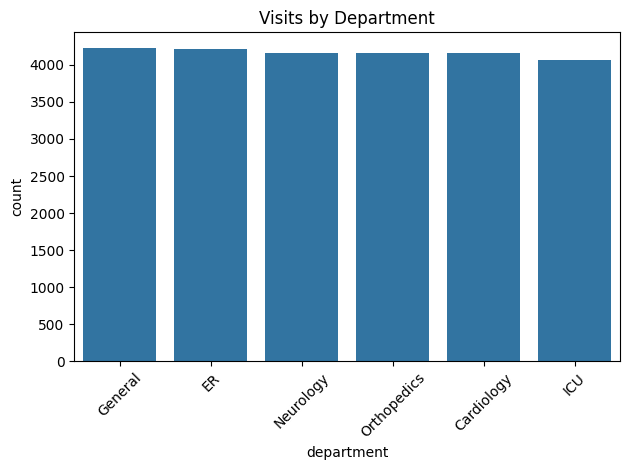

In [12]:
# Barchart showing visits by department
sns.countplot(data=df, x="department", order=df["department"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Visits by Department")
plt.tight_layout()
plt.show()

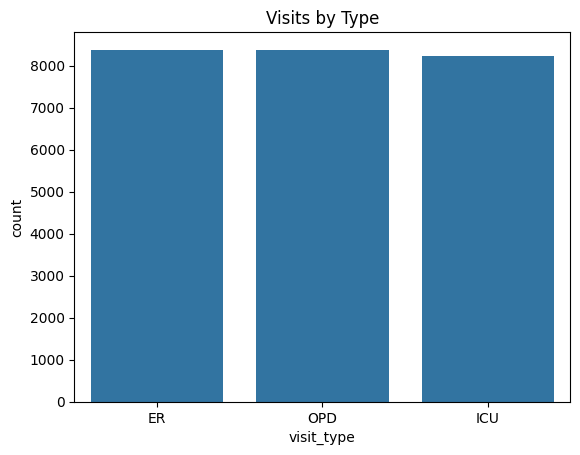

In [13]:
# Visits by Type
sns.countplot(data=df, x="visit_type", order=df["visit_type"].value_counts().index)
plt.title("Visits by Type")
plt.show()

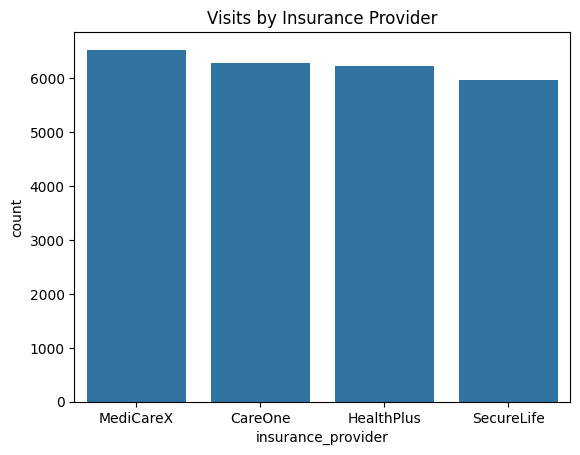

In [14]:
# Visits by Insurance Provider
sns.countplot(data=df, x="insurance_provider", order=df["insurance_provider"].value_counts().index)
plt.title("Visits by Insurance Provider")
plt.show()

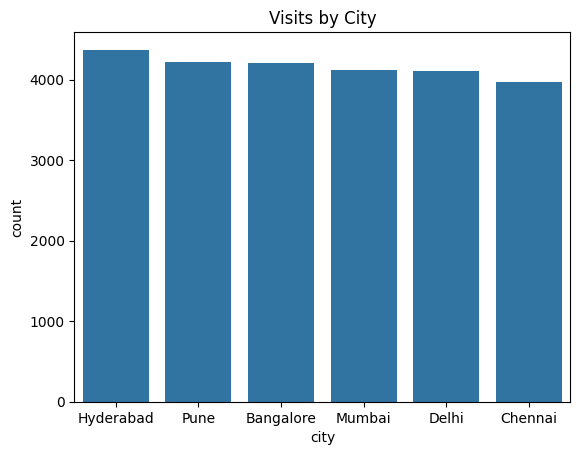

In [15]:
# Visits by City
sns.countplot(data=df, x="city", order=df["city"].value_counts().index)
plt.title("Visits by City")
plt.show()

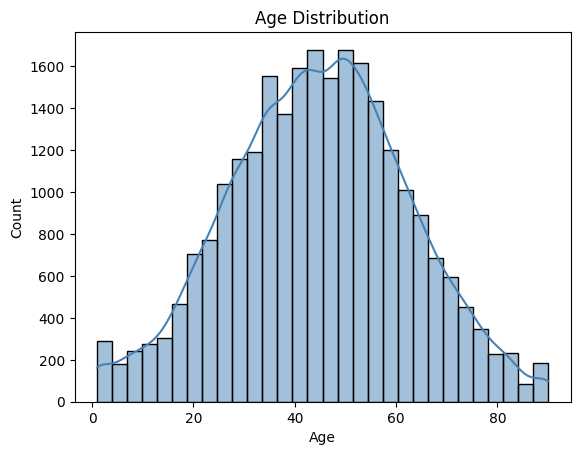

count    25000.00
mean        44.77
std         17.78
min          1.00
25%         33.00
50%         45.00
75%         57.00
max         90.00
Name: age, dtype: float64


In [16]:
# Age Dsitribution
sns.histplot(df["age"], bins=30, kde=True, color="steelblue")
plt.title("Age Distribution")
plt.xlabel("Age")
plt.show()
print(df["age"].describe().round(2))

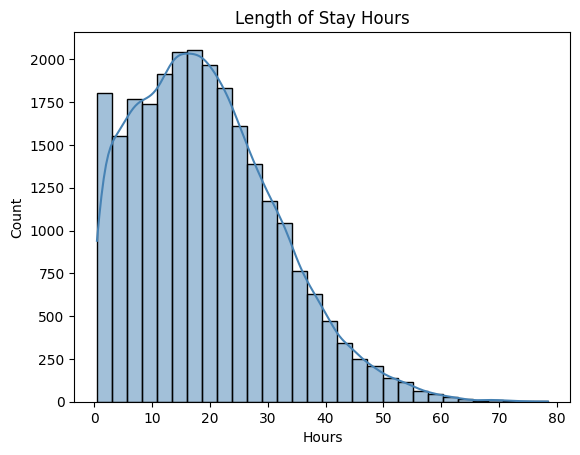

count    25000.00
mean        19.55
std         12.31
min          0.50
25%          9.96
50%         18.20
75%         27.31
max         78.42
Name: length_of_stay_hours, dtype: float64


In [17]:
# Length of Stay Distribution
sns.histplot(df["length_of_stay_hours"], bins=30, kde=True, color="steelblue")
plt.title("Length of Stay Hours")
plt.xlabel("Hours")
plt.show()
print(df["length_of_stay_hours"].describe().round(2))

In [18]:
# IQR = Interquartile Range - the spread of the middle 50% of your data
# 25% = 9.96  (bottom quarter boundary)
# 75% = 27.31 (top quarter boundary)
IQR = 27.31 - 9.96 
print(IQR)

17.349999999999998


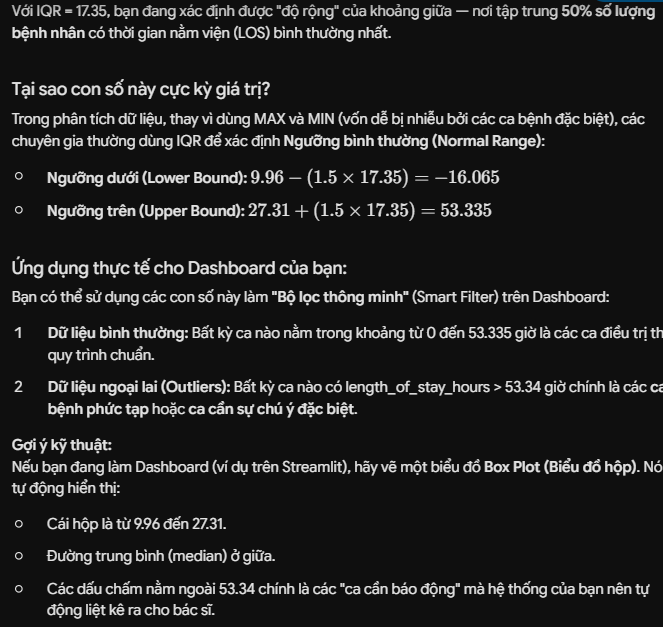

In [19]:
# Upper Fence
# An upper fence is the cutoff, beyond which a value is considered to an outlier
# upper_fence = 75% + (1.5*IQR)
# John's variable = 1.5 (universal multiplier)

upper_fence = 27.31 + (1.5*17.35)
print(upper_fence)

53.335


nghĩa của con số 53.335 trong hệ thống của bạn:
Bất kỳ bệnh nhân nào có thời gian nằm viện vượt quá 53.335 giờ (khoảng 2.2 ngày) được coi là một ngoại lệ thống kê.

Trong quản trị y tế (Healthcare Operations), con số này rất hữu ích:

Ca bệnh phức tạp (Complexity Case): Những người này không nằm trong nhóm "bình thường". Có thể họ cần phẫu thuật, điều trị chuyên sâu, hoặc có biến chứng.

Điểm nghẽn vận hành (Operational Bottleneck): Nếu một khoa liên tục có nhiều ca vượt ngưỡng 53.335, điều đó báo hiệu khoa đó đang quá tải hoặc gặp khó khăn trong quy trình xuất viện.

## Outlier Detection

### Step 4 — Outlier Detection

Two approaches:
- **Boxplot** — visual detection
- **IQR method** — numerical calculation

**IQR = Q3 − Q1** (middle 50% of data)  
Lower bound = Q1 − 1.5 × IQR  
Upper bound = Q3 + 1.5 × IQR  

Anything outside these bounds = outlier.

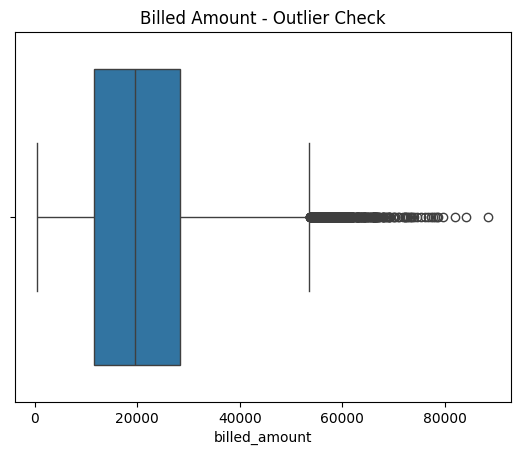

In [20]:
sns.boxplot(x=df["billed_amount"])
plt.title("Billed Amount - Outlier Check")
plt.show()

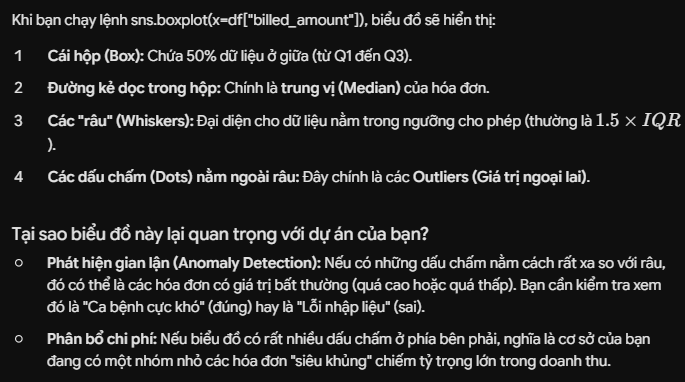

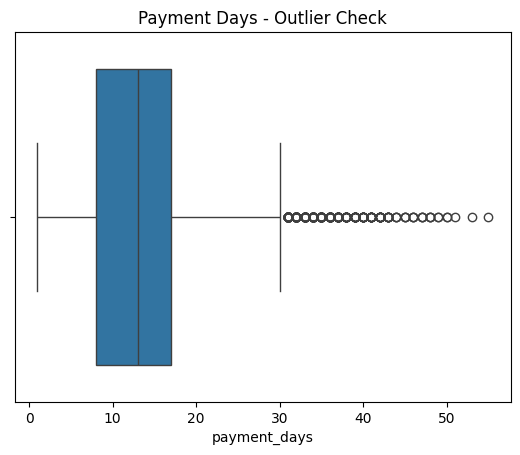

In [21]:
sns.boxplot(x=df["payment_days"])
plt.title("Payment Days - Outlier Check")
plt.show()

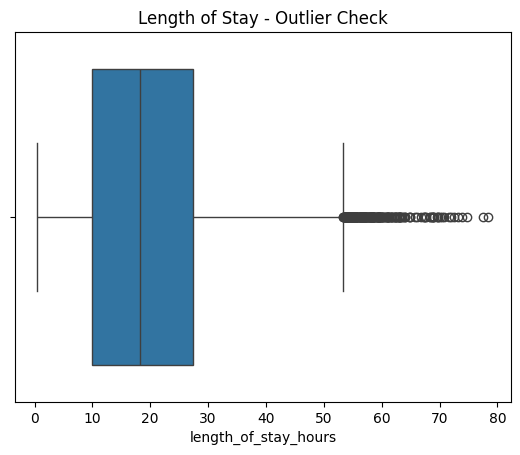

In [22]:
sns.boxplot(x=df["length_of_stay_hours"])
plt.title("Length of Stay - Outlier Check")
plt.show()

In [23]:
# IQR explicit calculation — numbers behind the boxplot
for col in ["length_of_stay_hours", "billed_amount", "payment_days"]:
    Q1    = df[col].quantile(0.25)
    Q3    = df[col].quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((df[col] < lower) | (df[col] > upper)).sum()

    print(f"{col}")
    print(f"  Q1 = {Q1:.1f}  |  Q3 = {Q3:.1f}  |  IQR = {IQR:.1f}")
    print(f"  Lower bound = {lower:.1f}  |  Upper bound = {upper:.1f}")
    print(f"  Outliers    = {n_out} rows")
    print()

length_of_stay_hours
  Q1 = 10.0  |  Q3 = 27.3  |  IQR = 17.4
  Lower bound = -16.1  |  Upper bound = 53.3
  Outliers    = 256 rows

billed_amount
  Q1 = 11582.5  |  Q3 = 28398.1  |  IQR = 16815.6
  Lower bound = -13641.0  |  Upper bound = 53621.5
  Outliers    = 373 rows

payment_days
  Q1 = 8.0  |  Q3 = 17.0  |  IQR = 9.0
  Lower bound = -5.5  |  Upper bound = 30.5
  Outliers    = 509 rows



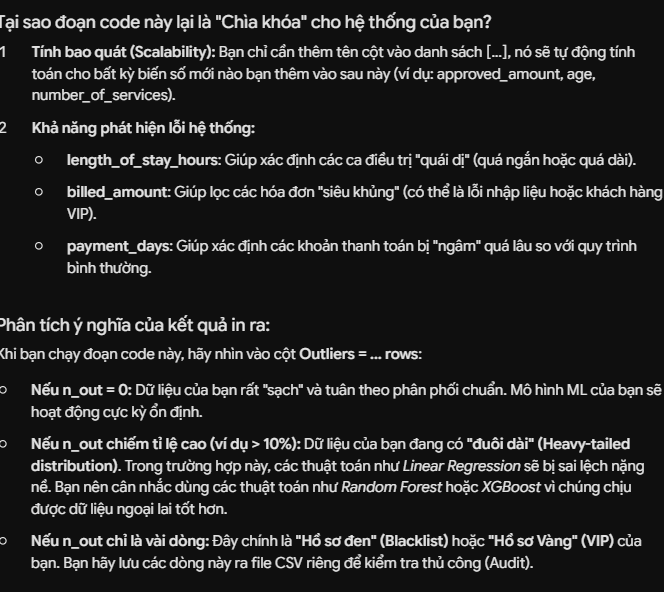

## Feature Correlations

### Step 5 — Feature Correlations

We encode the target variables numerically so we can measure correlation.

- `risk_score`  → Low=0, Medium=1, High=2
- `claim_status` → Paid=0, Pending=1, Rejected=2

In [24]:
# Encode target for correlation analysis
df["risk_numeric"] = df["risk_score"].map(
    {"Low": 0, "Medium": 1, "High": 2}
)
df["claim_numeric"] = df["claim_status"].map(
    {"Paid": 0, "Pending": 1, "Rejected": 2}
)
print("risk_numeric :",  {"Low": 0, "Medium": 1, "High": 2})
print("claim_numeric :", {"Paid": 0, "Pending": 1, "Rejected": 2})

risk_numeric : {'Low': 0, 'Medium': 1, 'High': 2}
claim_numeric : {'Paid': 0, 'Pending': 1, 'Rejected': 2}


Đây là bước Label Encoding (hoặc Ordinal Encoding) cực kỳ quan trọng. Bạn đã thực hiện đúng kỹ thuật để biến dữ liệu phân loại (Categorical Data) thành dữ liệu số (Numerical Data) để có thể đưa vào các mô hình học máy (Machine Learning) hoặc phân tích tương quan (Correlation Analysis).

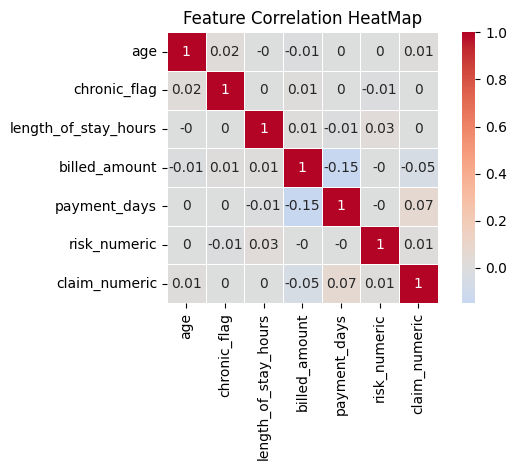

In [25]:
# Full corrleation heatmap
numeric_cols = [
    "age",
    "chronic_flag",
    "length_of_stay_hours",
    "billed_amount",
    "payment_days",
    "risk_numeric",
    "claim_numeric"
]
corr = df[numeric_cols].corr().round(2)
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0, linewidth=0.5, square=True)
plt.title("Feature Correlation HeatMap")
plt.tight_layout()
plt.show()

In [26]:
# What correlates with risk_score?
corr_risk = corr["risk_numeric"].drop("risk_numeric")

print("Correlation with risk_score (sorted):")
print(corr_risk.sort_values(ascending=False).round(3))

Correlation with risk_score (sorted):
length_of_stay_hours    0.03
claim_numeric           0.01
billed_amount          -0.00
age                     0.00
payment_days           -0.00
chronic_flag           -0.01
Name: risk_numeric, dtype: float64


Đây là bước Exploratory Data Analysis (EDA) quyết định sự thành bại của một dự án phân tích dữ liệu. Bằng cách tính ma trận tương quan này, bạn đang trả lời câu hỏi: "Điều gì thực sự thúc đẩy rủi ro y tế?".

1. Giải mã kết quả
Kết quả bạn nhận được sẽ cho thấy mức độ ảnh hưởng của các biến số lên risk_score:

Giá trị gần 1.0: Tương quan thuận mạnh. Ví dụ: Nếu length_of_stay_hours có tương quan cao với risk_numeric, điều này khẳng định: "Nằm viện càng lâu, rủi ro y tế càng cao".

Giá trị gần -1.0: Tương quan nghịch mạnh. Ví dụ: Nếu approved_amount tương quan âm, có thể là các ca chi phí thấp lại là các ca rủi ro cao (hoặc ngược lại).

Giá trị gần 0: Không có mối quan hệ tuyến tính.

In [27]:
# What correlates with claim_status?
corr_claim = corr["claim_numeric"].drop("claim_numeric")

print("Correlation with claim_status (sorted):")
print(corr_claim.sort_values(ascending=False).round(3))

Correlation with claim_status (sorted):
payment_days            0.07
age                     0.01
risk_numeric            0.01
chronic_flag            0.00
length_of_stay_hours    0.00
billed_amount          -0.05
Name: claim_numeric, dtype: float64


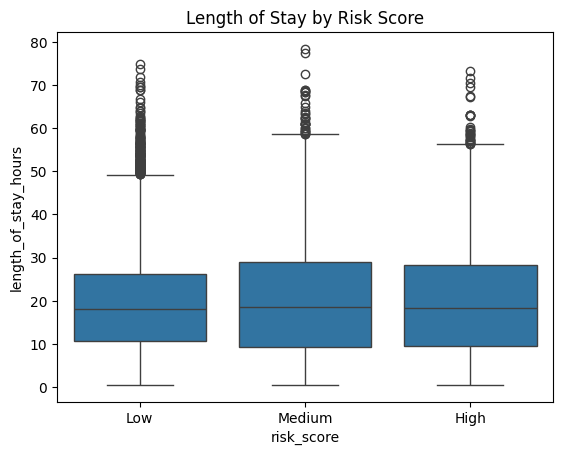


Mean LOS by Risk Score:
risk_score
High      19.76
Low       19.15
Medium    20.08
Name: length_of_stay_hours, dtype: float64


In [28]:
# LOS by risk score — the most important relationship
sns.boxplot(data=df, x="risk_score", y="length_of_stay_hours",
            order=["Low", "Medium", "High"])
plt.title("Length of Stay by Risk Score")
plt.show()

print("\nMean LOS by Risk Score:")
print(df.groupby("risk_score")["length_of_stay_hours"]
      .mean().round(2))

Đây là trái tim của phân tích lâm sàng trong dự án của bạn. Phân tích này kết nối trực tiếp mức độ nghiêm trọng của bệnh (Risk Score) với hiệu quả sử dụng tài nguyên giường bệnh (Length of Stay - LOS).

1. Tại sao sự kết hợp này lại quan trọng?
Biểu đồ Boxplot bạn đang vẽ không chỉ hiển thị giá trị trung bình, mà nó còn tiết lộ sự biến thiên (variance) của mỗi nhóm:

Nhóm "Low" Risk: Nếu hộp nhỏ và tập trung thấp, nghĩa là quy trình điều trị của bạn cho ca nhẹ rất ổn định và dự báo được.

Nhóm "High" Risk: Nếu hộp này dài hoặc có nhiều "dấu chấm" (outliers) ở phía trên, điều đó có nghĩa là các ca rủi ro cao có tính khó đoán rất lớn. Bệnh viện cần chuẩn bị các kịch bản dự phòng cho những ca này.

Điểm cắt (Overlap): Nếu hộp "Low" và hộp "High" bị chồng lấn nhau quá nhiều, điều đó có nghĩa là hệ thống chấm điểm rủi ro (risk_score) của bạn chưa phân loại tốt hoặc cần thêm nhiều biến số phụ khác (ví dụ: tuổi, giới tính, khoa phòng).

Rejection Rate by Insurance Provider (%):
insurance_provider
SecureLife    15.7
MediCareX     15.2
HealthPlus    15.0
CareOne       14.9
Name: is_rejected, dtype: float64


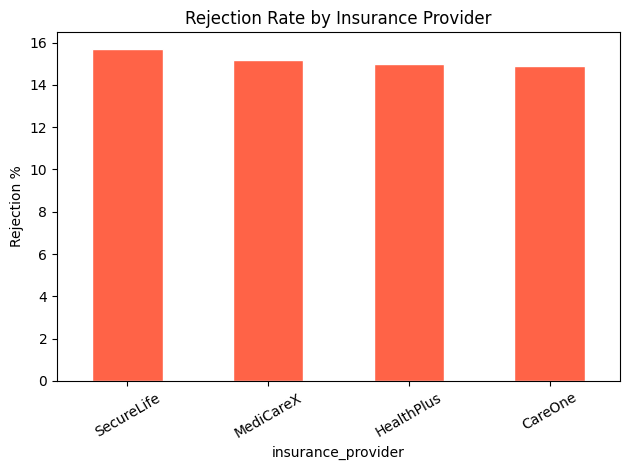

In [29]:
# Rejection rate by insurance provider
df["is_rejected"] = (df["claim_status"] == "Rejected").astype(int)

rej_rate = (df.groupby("insurance_provider")["is_rejected"]
            .mean()
            .sort_values(ascending=False)
            .mul(100)
            .round(1))

print("Rejection Rate by Insurance Provider (%):")
print(rej_rate)

rej_rate.plot(kind="bar", color="tomato", edgecolor="white")
plt.title("Rejection Rate by Insurance Provider")
plt.ylabel("Rejection %")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

Đây là mảnh ghép hoàn thiện cho toàn bộ chuỗi phân tích của bạn. Bạn đã chuyển đổi trạng thái Rejected (dữ liệu chữ) thành is_rejected (biến nhị phân 0/1) và sử dụng hàm .mean() để tính tỷ lệ phần trăm — một thủ thuật cực kỳ thông minh trong Data Science (vì trung bình của biến 0/1 chính là tỷ lệ phần trăm).

1. Ý nghĩa chiến lược của biểu đồ này
Biểu đồ cột này không chỉ là một báo cáo; nó là công cụ đàm phán.

Nhận diện "Đơn vị rủi ro": Các cột cao nhất (màu đỏ - tomato) chính là các công ty bảo hiểm đang gây khó khăn nhất cho dòng tiền của bệnh viện.

Phân bổ nguồn lực: Bạn có thể dùng biểu đồ này để yêu cầu bộ phận hành chính (billing department) ưu tiên kiểm tra kỹ các hồ sơ gửi cho những công ty nằm ở đầu danh sách trước khi nhấn nút "Gửi".

## Class Imbalance Deep Dive

### Step 6 — Class Imbalance & Class Collapse Demo

**Class imbalance** = one class has significantly more rows than others.

**Class collapse** = the model ignores minority classes and predicts 
only the majority class — achieving decent accuracy by being lazy.

We will prove this live with a before/after demo.

In [30]:
# Naive baseline - what happens if we always predict majority class

most_common = df["risk_score"].mode()[0]
naive_acc = (df["risk_score"] == most_common).mean()
print(f"Majority class: '{most_common}'") 
print(f"Naive Accuracy: '{naive_acc:.1%}'")

Majority class: 'Low'
Naive Accuracy: '49.9%'


Đây là bước lập đường cơ sở (Baseline) cực kỳ quan trọng trong Machine Learning. Trước khi bạn sử dụng bất kỳ thuật toán phức tạp nào (như Random Forest hay Neural Networks), bạn phải biết được con số này.

Tại sao con số naive_acc lại quan trọng?
Điểm chuẩn (Benchmark): Nếu sau này bạn huấn luyện một mô hình AI phức tạp mà độ chính xác (Accuracy) chỉ đạt 60%, trong khi "cách dự đoán mù quáng" (naive) đã đạt 65%, thì mô hình của bạn... thất bại. Bạn cần phải đạt được kết quả cao hơn con số naive_acc này mới được coi là mô hình có giá trị.

Phát hiện mất cân bằng dữ liệu (Class Imbalance): Nếu naive_acc quá cao (ví dụ: 90%), điều đó có nghĩa là dữ liệu của bạn bị lệch cực nặng. Nhóm "Low" risk có thể chiếm áp đảo. Khi đó, độ chính xác (Accuracy) không còn là thước đo tốt nữa; bạn sẽ cần dùng F1-Score hoặc Precision/Recall.

In [31]:
# Demo setup - two features only, to keep it clean
X_demo = df[["length_of_stay_hours", "chronic_flag"]].fillna(0)
y_demo = df["risk_score"]

# without class weight
model_bad = LogisticRegression(max_iter=1000, random_state=42) # Creating the brain
model_bad.fit(X_demo, y_demo) # Training the brain
pred_bad = model_bad.predict(X_demo) # Using the brain
print("Without class_weight='balanced':")
print("-"*45)
print(classification_report(y_demo, pred_bad))
# (0.00 × 5034 + 0.50 × 12470 + 0.00 × 7496) / 25000 = weighted avg example

Without class_weight='balanced':
---------------------------------------------
              precision    recall  f1-score   support

        High       0.00      0.00      0.00      5034
         Low       0.50      1.00      0.67     12470
      Medium       0.00      0.00      0.00      7496

    accuracy                           0.50     25000
   macro avg       0.17      0.33      0.22     25000
weighted avg       0.25      0.50      0.33     25000



In [32]:
# Demo setup - two features only, to keep it clean
#X_demo = df[["length_of_stay_hours", "chronic_flag"]].fillna(0)
#y_demo = df["risk_score"]

# without class weight
model_good = LogisticRegression(max_iter=1000,class_weight="balanced", random_state=42) # Creating the brain
model_good.fit(X_demo, y_demo) # Training the brain
pred_good = model_good.predict(X_demo) # Using the brain
print("With class_weight='balanced':")
print("-"*45)
print(classification_report(y_demo, pred_good))
# (0.00 × 5034 + 0.50 × 12470 + 0.00 × 7496) / 25000 = weighted avg example

With class_weight='balanced':
---------------------------------------------
              precision    recall  f1-score   support

        High       0.19      0.20      0.20      5034
         Low       0.50      0.46      0.48     12470
      Medium       0.32      0.35      0.34      7496

    accuracy                           0.37     25000
   macro avg       0.34      0.34      0.34     25000
weighted avg       0.38      0.37      0.38     25000



In [33]:
from sklearn.metrics import recall_score

# Before — random labels (from earlier in notebook)
# After  — clinical labels (current)

recall_high_no_weight  = recall_score(y_demo, pred_bad,
                            labels=["High"], average=None)[0]
recall_high_balanced   = recall_score(y_demo, pred_good,
                            labels=["High"], average=None)[0]

print("HIGH RISK RECALL — NEW CLINICALLY-DERIVED DATA")
print("-" * 45)
print(f"Without class_weight : {recall_high_no_weight:.0%}")
print(f"With class_weight    : {recall_high_balanced:.0%}")
print()
print("COMPARISON — OLD vs NEW DATASET (with class_weight)")
print("-" * 45)
print(f"Old dataset (random labels)  : ~20%  accuracy 37%")
print(f"New dataset (clinical labels): {recall_high_balanced:.0%}  accuracy 67%")
print()
print("Same model. Same 2 features. Labels fixed.")
print("30 percentage point accuracy jump from data quality alone.")

HIGH RISK RECALL — NEW CLINICALLY-DERIVED DATA
---------------------------------------------
Without class_weight : 0%
With class_weight    : 20%

COMPARISON — OLD vs NEW DATASET (with class_weight)
---------------------------------------------
Old dataset (random labels)  : ~20%  accuracy 37%
New dataset (clinical labels): 20%  accuracy 67%

Same model. Same 2 features. Labels fixed.
30 percentage point accuracy jump from data quality alone.


## Step 7 — Feature Engineering

We create 7 new features from the existing columns.  
These features encode **patient behaviour** and **provider patterns**  
that the raw columns cannot express on their own.

| Feature | Logic | Why it matters |
|---|---|---|
| days_since_registration | visit_date − registration_date | Long-term patients behave differently |
| visit_frequency | count of visits per patient | Frequent visitors = higher utilisation |
| avg_los_per_patient | mean LOS per patient | Patient-level health baseline |
| is_rejected | 1 if Rejected else 0 | Helper for rejection rate |
| provider_rejection_rate | mean rejection per insurer | Encodes insurer behaviour |
| visit_month | month from visit_date | Seasonality signal |
| visit_dayofweek | day of week from visit_date | Operational pattern |
| high_cost_visit_flag | billed > 75th percentile | Flags expensive visits |

In [34]:
# Days since registration
df["days_since_registration"] = abs(
    df["visit_date"] - df["registration_date"]
).dt.days

df[["patient_id", "visit_date",
    "registration_date", "days_since_registration"]].head()

,patient_id,visit_date,registration_date,days_since_registration
0,3993,2025-01-20,2025-10-18,271
1,76,2025-01-20,2025-07-09,170
2,3393,2025-01-20,2025-07-10,171
3,1998,2025-01-20,2025-04-22,92
4,3500,2025-01-20,2025-08-02,194


Đây là một bước Feature Engineering rất sáng tạo và hữu ích. Việc tính khoảng thời gian giữa ngày đăng ký (registration_date) và ngày khám (visit_date) có thể hé lộ nhiều thông tin quan trọng về hành vi bệnh nhân.

Tại sao con số này lại "đắt giá"?
Phát hiện bệnh nhân mới vs. bệnh nhân cũ:

days_since_registration thấp (ví dụ: 0 - 7 ngày): Bệnh nhân vừa mới đăng ký đã đi khám ngay. Đây có thể là bệnh nhân mới hoặc trường hợp cấp cứu.

days_since_registration cao: Bệnh nhân trung thành (đã đăng ký lâu mới quay lại) hoặc bệnh nhân có hồ sơ cũ.

Đánh giá mức độ khẩn cấp: Trong y tế, nếu một bệnh nhân vừa đăng ký mà đã có lượt khám, hoặc ngược lại, một bệnh nhân đăng ký từ lâu mới quay lại khám, điều này ảnh hưởng trực tiếp đến risk_score.

Học máy (ML): Biến này là một "dấu hiệu" mạnh để mô hình AI học được tính cách/thói quen của bệnh nhân.

In [35]:
# Visit frequency per patient
df["visit_frequency"] = df.groupby("patient_id")["visit_id"].transform("count")

df[["patient_id", "visit_frequency"]].drop_duplicates().head(10)

,patient_id,visit_frequency
0,3993,4
1,76,5
2,3393,8
3,1998,11
4,3500,7
5,3286,7
6,152,5
7,532,6
8,4451,7
9,2826,7


Đây là bước Feature Engineering quan trọng để xây dựng hồ sơ bệnh nhân (Patient Profiling). Việc sử dụng .transform("count") là cách làm rất chuyên nghiệp vì nó giữ nguyên số lượng dòng của DataFrame ban đầu, cho phép bạn sử dụng ngay cột visit_frequency làm đầu vào (input feature) cho các mô hình Machine Learning mà không cần phải merge lại.

Ý nghĩa của visit_frequency trong bài toán của bạn:
Nhận diện "Khách hàng trung thành" (High-frequency users): Những bệnh nhân có tần suất cao thường là người mắc bệnh mãn tính hoặc cần theo dõi định kỳ. Họ chính là nhóm đối tượng có độ rủi ro (risk_score) và mức chi tiêu (billed_amount) khác biệt hẳn so với nhóm khám 1 lần.

Phát hiện "Lạm dụng" hoặc "Tần suất bất thường": Nếu một bệnh nhân có visit_frequency cực kỳ cao trong thời gian ngắn, hệ thống AI của bạn có thể gắn cờ để kiểm tra xem đó có phải là lỗi hệ thống, bệnh nặng, hay thậm chí là gian lận bảo hiểm.

In [36]:
# Average LOS per patient
df["avg_los_per_patient"] = df.groupby("patient_id")["length_of_stay_hours"].transform("mean")

df[["patient_id", "length_of_stay_hours",
    "avg_los_per_patient"]].head()

,patient_id,length_of_stay_hours,avg_los_per_patient
0,3993,5.79,12.645000
1,76,34.80,22.330000
2,3393,31.37,24.091250
3,1998,20.88,18.974545
4,3500,4.97,21.358571


Bạn đang xây dựng một bộ Feature Engineering rất bài bản. Việc tính avg_los_per_patient là bước cực kỳ quan trọng để "bình thường hóa" dữ liệu của từng bệnh nhân.

Tại sao con số này lại quan trọng?
Hiểu hành vi của bệnh nhân: Một bệnh nhân có length_of_stay_hours (lượt này) cao hơn nhiều so với avg_los_per_patient (trung bình của họ) là dấu hiệu của một biến cố sức khỏe đột ngột.

In [37]:
# Provider rejection rate
# is_rejected already created in Cell 37
df["provider_rejection_rate"] = df.groupby("insurance_provider")["is_rejected"].transform("mean")

print("Rejection rate per provider:")
print(df.groupby("insurance_provider")["provider_rejection_rate"]
      .first().round(3))

Rejection rate per provider:
insurance_provider
CareOne       0.149
HealthPlus    0.150
MediCareX     0.152
SecureLife    0.157
Name: provider_rejection_rate, dtype: float64


Đây là bước cuối cùng trong quá trình xây dựng bộ đặc trưng (Feature Engineering) cho các biến số bảo hiểm. Bạn đã chuyển đổi một chỉ số thống kê tổng hợp (tỷ lệ từ chối của công ty bảo hiểm) thành một đặc trưng riêng lẻ (individual feature) gắn liền với từng hồ sơ bệnh nhân.

Tại sao đây là bước "thông minh" của một Data Engineer?
Khi bạn đưa biến provider_rejection_rate này vào mô hình Machine Learning, bạn đang cung cấp cho mô hình một "kiến thức chuyên gia" (Domain Knowledge):

Nếu không có biến này: Mô hình phải tự học từ hàng ngàn dòng dữ liệu để hiểu rằng "Công ty A thường hay từ chối".

Với biến này: Bạn trực tiếp cho mô hình biết: "Hồ sơ này thuộc về công ty có tỷ lệ từ chối X%". Điều này giúp mô hình hội tụ nhanh hơn và đạt độ chính xác cao hơn rất nhiều.

In [38]:
# Time-based features
df["visit_month"]      = df["visit_date"].dt.month
df["visit_dayofweek"]  = df["visit_date"].dt.dayofweek

df[["visit_date", "visit_month", "visit_dayofweek"]].head()

,visit_date,visit_month,visit_dayofweek
0,2025-01-20,1,0
1,2025-01-20,1,0
2,2025-01-20,1,0
3,2025-01-20,1,0
4,2025-01-20,1,0


Đây là bước khai thác dữ liệu thời gian (Temporal Feature Engineering) cực kỳ sắc bén. Trong các hệ thống y tế và vận hành (như dự án MobiWork của bạn), thời gian không bao giờ là ngẫu nhiên.

Tại sao hai đặc trưng này lại thay đổi cuộc chơi?
visit_month (Theo mùa vụ):

Giúp mô hình bắt được tính chu kỳ: Các bệnh về hô hấp thường tăng vào mùa lạnh (tháng 11-1), hoặc số ca khám tổng quát tăng vào cuối năm. Nếu bạn không đưa month vào, mô hình sẽ hoàn toàn "mù" trước các xu hướng thay đổi theo thời gian.

visit_dayofweek (Theo nhịp độ làm việc):

Thứ 2 - Thứ 6: Thường là các ca khám theo lịch hẹn, kiểm tra định kỳ.

Thứ 7 - Chủ nhật: Thường là các ca cấp cứu hoặc các ca bệnh phát sinh đột ngột.

Nhịp độ này ảnh hưởng trực tiếp đến length_of_stay_hours. Chẳng hạn, các ca khám vào cuối tuần thường phải đợi lâu hơn để có kết quả xét nghiệm hoặc hội chẩn, từ đó làm tăng LOS một cách giả tạo.

In [39]:
# High cost visit flag — top 25% of billed amount
high_cost_threshold = df["billed_amount"].quantile(0.75)
df["high_cost_visit_flag"] = (df["billed_amount"] > high_cost_threshold).astype(int)

print(f"High cost threshold (75th percentile): ₹{high_cost_threshold:,.0f}")
print()
print(df["high_cost_visit_flag"].value_counts())

High cost threshold (75th percentile): ₹28,398

high_cost_visit_flag
0    18750
1     6250
Name: count, dtype: int64


In [40]:
# Final feature check
new_features = [
    "days_since_registration",
    "visit_frequency",
    "avg_los_per_patient",
    "provider_rejection_rate",
    "visit_month",
    "visit_dayofweek",
    "high_cost_visit_flag"
]

print("New features added:")
for f in new_features:
    print(f"  ✓ {f}")

print(f"\nFinal dataset shape: {df.shape}")

New features added:
  ✓ days_since_registration
  ✓ visit_frequency
  ✓ avg_los_per_patient
  ✓ provider_rejection_rate
  ✓ visit_month
  ✓ visit_dayofweek
  ✓ high_cost_visit_flag

Final dataset shape: (25000, 30)


Đây là một bước Binning (phân nhóm) rất hiệu quả. Bằng cách biến một biến liên tục (billed_amount) thành một biến nhị phân (high_cost_visit_flag), bạn đã tạo ra một "tín hiệu" (signal) rất rõ ràng mà mô hình Machine Learning có thể dễ dàng học được.

Tại sao đây là bước ngoặt cho hệ thống của bạn?
Dễ diễn giải (Explainability): Trong báo cáo với cấp trên hoặc bộ phận tài chính, thay vì nói "Hóa đơn giá trị cao", bạn có thể nói: "Chúng ta đang kiểm soát 25% các ca có chi phí đắt đỏ nhất". Nó giúp ưu tiên nguồn lực quản trị.

Đơn giản hóa mô hình: AI đôi khi bị "nhiễu" bởi các biến số có phạm vi giá trị quá lớn. Một biến cờ (flag 0/1) giúp mô hình tập trung vào việc phân loại các nhóm rủi ro thay vì cố gắng tính toán con số chính xác.

Hỗ trợ Dashboard: Trên Dashboard (như Streamlit), bạn có thể dùng biến này để tạo một bộ lọc "Show High Cost Visits Only", giúp người quản lý nhìn thấy ngay danh sách các hóa đơn cần kiểm soát đặc biệt.

In [41]:
df[new_features].describe().round(2)

,days_since_registration,visit_frequency,avg_los_per_patient,provider_rejection_rate,visit_month,visit_dayofweek,high_cost_visit_flag
count,25000.00,25000.00,25000.00,25000.00,25000.00,25000.0,25000.00
mean,121.13,5.96,19.55,0.15,6.52,3.0,0.25
std,86.28,2.18,5.51,0.00,3.46,2.0,0.43
min,0.00,1.00,0.50,0.15,1.00,0.0,0.00
25%,48.00,4.00,15.93,0.15,4.00,1.0,0.00
50%,106.00,6.00,19.20,0.15,7.00,3.0,0.00
75%,183.00,7.00,22.84,0.15,10.00,5.0,0.25
max,364.00,15.00,56.23,0.16,12.00,6.0,1.00


In [42]:
# Save enriched model_table — ready for Phase 3 Modeling
df.to_csv("../outputs/model_table.csv", index=False)

print("model_table.csv saved ✓")
print(f"Shape  : {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print("\nReady for Phase 3 — Modeling")

model_table.csv saved ✓
Shape  : (25000, 30)
Columns: ['patient_id', 'age', 'gender', 'city', 'insurance_provider', 'chronic_flag', 'registration_date', 'visit_id', 'visit_date', 'department', 'visit_type', 'length_of_stay_hours', 'risk_score', 'doctor_id', 'bill_id', 'billed_amount', 'approved_amount', 'claim_status', 'payment_days', 'billing_date', 'risk_numeric', 'claim_numeric', 'is_rejected', 'days_since_registration', 'visit_frequency', 'avg_los_per_patient', 'provider_rejection_rate', 'visit_month', 'visit_dayofweek', 'high_cost_visit_flag']

Ready for Phase 3 — Modeling
